## Subagents

- Main agent uses the file system not its subagents

In [1]:
from typing import Annotated, NotRequired

from langchain.agents import create_agent  # updated 1.0
from langchain_core.messages import ToolMessage
from langchain_core.tools import BaseTool, InjectedToolCallId, tool
from langgraph.prebuilt import InjectedState  # updated 1.0
from langgraph.types import Command
from prompts import TASK_DESCRIPTION_PREFIX
from state import DeepAgentState
from typing_extensions import TypedDict


In [2]:
class SubAgent(TypedDict):
    """Configuration for a specialized sub-agent."""

    name: str
    description: str
    prompt: str
    tools: NotRequired[list[str]]

In [3]:
def _create_task_tool(tools, subagents: list[SubAgent], model, state_schema):
    """Create a task delegation tool that enables context isolation through sub-agents.

    This function implements the core pattern for spawning specialized sub-agents with
    isolated contexts, preventing context clash and confusion in complex multi-step tasks.

    Args:
        tools: List of available tools that can be assigned to sub-agents
        subagents: List of specialized sub-agent configurations
        model: The language model to use for all agents
        state_schema: The state schema (typically DeepAgentState)

    Returns:
        A 'task' tool that can delegate work to specialized sub-agents
    """
    # Create agent registry
    agents = {}

    # Build tool name mapping for selective tool assignment
    tools_by_name = {}
    for tool_ in tools:
        if not isinstance(tool_, BaseTool):
            tool_ = tool(tool_)
        tools_by_name[tool_.name] = tool_

    # Create specialized sub-agents based on configurations
    for _agent in subagents:
        if "tools" in _agent:
            # Use specific tools if specified
            _tools = [tools_by_name[t] for t in _agent["tools"]]
        else:
            # Default to all tools
            _tools = tools
        agents[_agent["name"]] = create_agent(   # updated 1.0
            model, system_prompt=_agent["prompt"], tools=_tools, state_schema=state_schema
        )

    # Generate description of available sub-agents for the tool description
    other_agents_string = [
        f"- {_agent['name']}: {_agent['description']}" for _agent in subagents
    ]

    @tool(description=TASK_DESCRIPTION_PREFIX.format(other_agents=other_agents_string))
    def task(
        description: str,
        subagent_type: str,
        state: Annotated[DeepAgentState, InjectedState],
        tool_call_id: Annotated[str, InjectedToolCallId],
    ):
        """Delegate a task to a specialized sub-agent with isolated context.

        This creates a fresh context for the sub-agent containing only the task description,
        preventing context pollution from the parent agent's conversation history.
        """
        # Validate requested agent type exists
        if subagent_type not in agents:
            return f"Error: invoked agent of type {subagent_type}, the only allowed types are {[f'`{k}`' for k in agents]}"

        # Get the requested sub-agent
        sub_agent = agents[subagent_type]

        # Create isolated context with only the task description
        # This is the key to context isolation - no parent history
        state["messages"] = [{"role": "user", "content": description}]

        # Execute the sub-agent in isolation
        result = sub_agent.invoke(state)

        # Return results to parent agent via Command state update
        return Command(
            update={
                "files": result.get("files", {}),  # Merge any file changes
                "messages": [
                    # Sub-agent result becomes a ToolMessage in parent context
                    ToolMessage(
                        result["messages"][-1].content, tool_call_id=tool_call_id
                    )
                ],
            }
        )

    return task

In [ ]:
from prompts import SUBAGENT_USAGE_INSTRUCTIONS
from utils import show_prompt

show_prompt(SUBAGENT_USAGE_INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  You can delegate tasks to sub-agents.                                                                          │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  Your role is to coordinate research by delegating specific research tasks to sub-agents.                       │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Tools>                                                                                              │
│  1. **task(description, subagent_type)**: Delegate research tasks to specialized sub-agents                     │
│     - description: Clear, specific research question or task                                                    │
│     - subagent_type: Type of agent to use (e.g., "research-agent")                                              │
│  2. **think_tool(reflection)**: Reflect on the results of each delegated task and plan next steps.              │
│     - reflection: Your detailed reflection on the results of the task and next steps.                           │
│                                                                                                                 │
│  **PARALLEL RESEARCH**: When you identify multiple independent research directions, make multiple **task**      │
│  tool calls in a single response to enable parallel execution. Use at most {max_concurrent_research_units}      │
│  parallel agents per iteration.                                                                                 │
│  </Available Tools>                                                                                             │
│                                                                                                                 │
│  <Hard Limits>                                                                                                  │
│  **Task Delegation Budgets** (Prevent excessive delegation):                                                    │
│  - **Bias towards focused research** - Use single agent for simple questions, multiple only when clearly        │
│  beneficial or when you have multiple independent research directions based on the user's request.              │
│  - **Stop when adequate** - Don't over-research; stop when you have sufficient information                      │
│  - **Limit iterations** - Stop after {max_researcher_iterations} task delegations if you haven't found          │
│  adequate sources                                                                                               │
│  </Hard Limits>                                                                                                 │
│                                                                                                                 │
│  <Scaling Rules>                                                                                                │
│  **Simple fact-finding, lists, and rankings** can use a single sub-agent:                                       │
│  - *Example*: "List the top 10 coffee shops in San Francisco" → Use 1 sub-agent, store in                       │
│  `findings_coffee_shops.md`                                                                                     │
│                                                                                                                 │
│  **Comparisons** can use a sub-agent for each element 

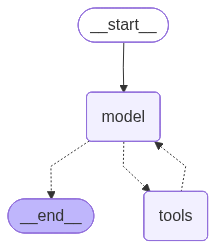

In [5]:
from datetime import datetime

from IPython.display import Image, display

#from langgraph.prebuilt import create_react_agent
from langchain.agents import create_agent  # updated in 1.0
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool
from prompts import SUBAGENT_USAGE_INSTRUCTIONS
from state import DeepAgentState

# Limits
max_concurrent_research_units = 3
max_researcher_iterations = 3

# Mock search result
search_result = """The Model Context Protocol (MCP) is an open standard protocol developed 
by Anthropic to enable seamless integration between AI models and external systems like 
tools, databases, and other services. It acts as a standardized communication layer, 
allowing AI models to access and utilize data from various sources in a consistent and 
efficient manner. Essentially, MCP simplifies the process of connecting AI assistants 
to external services by providing a unified language for data exchange. """


# Mock search tool
@tool(parse_docstring=True)
def web_search(
    query: str,
):
    """Search the web for information on a specific topic.

    This tool performs web searches and returns relevant results
    for the given query. Use this when you need to gather information from
    the internet about any topic.

    Args:
        query: The search query string. Be specific and clear about what
               information you're looking for.

    Returns:
        Search results from the search engine.

    Example:
        web_search("machine learning applications in healthcare")
    """
    return search_result


# Add mock research instructions
SIMPLE_RESEARCH_INSTRUCTIONS = """You are a researcher. Research the topic provided to you. IMPORTANT: Just make a single call to the web_search tool and use the result provided by the tool to answer the provided topic."""

# Create research sub-agent
research_sub_agent = {
    "name": "research-agent",
    "description": "Delegate research to the sub-agent researcher. Only give this researcher one topic at a time.",
    "prompt": SIMPLE_RESEARCH_INSTRUCTIONS,
    "tools": ["web_search"],
}

# Create agent using create_react_agent directly
model = init_chat_model(model="openai:gpt-5.2", temperature=0.0)

# Tools for sub-agent
sub_agent_tools = [web_search]

# Create task tool to delegate tasks to sub-agents
task_tool = _create_task_tool(
    sub_agent_tools, [research_sub_agent], model, DeepAgentState
)

# Tools
delegation_tools = [task_tool]

# Create agent with system prompt
agent = create_agent(
    model,
    delegation_tools,
    system_prompt=SUBAGENT_USAGE_INSTRUCTIONS.format(
        max_concurrent_research_units=max_concurrent_research_units,
        max_researcher_iterations=max_researcher_iterations,
        date=datetime.now().strftime("%a %b %-d, %Y"),
    ),
    state_schema=DeepAgentState,
)

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [6]:
from utils import format_messages

result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Give me an overview of Model Context Protocol (MCP).",
            }
        ],
    }
)

format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Give me an overview of Model Context Protocol (MCP).                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: task                                                                                              │
│    Args: {                                                                                                      │
│   "description": "Provide a concise technical overview of Model Context Protocol (MCP): what it is, core        │
│ concepts, architecture, key components, how it works, typical use cases, and security considerations. Include   │
│ accurate details as of 2025-08.",                                                                               │
│   "subagent_type": "research-agent"                                                                             │
│ }                                                                                                               │
│    ID: call_C6PBse01suVnBYGvkYm0aVwO                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ ## Model Context Protocol (MCP) — concise technical overview (as of 2025-08)                                    │
│                                                                                                                 │
│ ### What it is                                                                                                  │
│ **Model Context Protocol (MCP)** is an **open standard** (originated by Anthropic) for connecting **LLM-powered │
│ clients** (chat apps, IDE assistants, agents) to **external context and capabilities** (tools, data sources,    │
│ services) through a **uniform, model-agnostic interface**.                                                      │
│ Its goal is to replace one-off “plugin” integrations with a consistent protocol so any MCP-capable client can   │
│ work with any MCP server.                                                                                       │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ## Core concepts                                                                                                │
│ - **MCP Client**: The LLM host application (e.g., a desktop assistant, IDE extension, agent runtime). It:       │
│   - negotiates capabilities with servers,                                                                       │
│   - presents available tools/resources/prompts to the model,                                                    │
│   - executes protocol calls and returns results to the model.                                                   │
│                                                                                                                 │
│ - **MCP Server**: A process/service that exposes:                                                               │
│   - **Tools** (callable functions with JSON-ish I/O),                                                           │
│   - **Resources** (readable data objects, often addressed by URI-like identifiers),                             │
│   - **Prompts** (reusable prompt templates / interaction patterns).                                             │
│   Servers encapsulate authentication to upstream systems (e.g., GitHub, Slack, databases) and enforce access    │
│ control.                                                                                                        │
│                                                                                                                 │
│ - **Tools**: Structured, callable operations (e.g., `search_issues`, `run_sql`, `create_ticket`). Tools have    │
│ machine-readable schemas so the model/client can validate arguments and parse outputs.                          │
│                                                                                                                 │
│ - **Resources**: Context the model can fetch/inspect (files, documents, database entities, logs). Typically     │
│ support:                                                                                                        │
│   - metadata discovery,                                                                                         │
│   - content retrieval,                                                                                          │
│   - sometimes subscription/streaming for updates.                                                               │
│                                                                                                                 │
│ - **Prompts**: Server-provided prompt templates / “reci

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Model Context Protocol (MCP) is an **open, model-agnostic client–server protocol** for giving LLM applications  │
│ a standardized way to access **external tools and data**. It was introduced by Anthropic to reduce the “N       │
│ different plugin APIs” problem: instead of building a custom integration for each app and each data source, you │
│ implement (or install) an **MCP server** once, and any **MCP-capable client** can use it.                       │
│                                                                                                                 │
│ ## What MCP standardizes                                                                                        │
│ MCP defines how an LLM host app discovers and uses three main kinds of capabilities exposed by a server:        │
│                                                                                                                 │
│ 1. **Tools**                                                                                                    │
│    Callable functions with structured inputs/outputs (think: “function calling” but provided by an external     │
│ server).                                                                                                        │
│    Examples: `search_repo`, `run_sql`, `create_ticket`, `send_message`.                                         │
│                                                                                                                 │
│ 2. **Resources**                                                                                                │
│    Readable context objects the model can fetch—often identified by URI-like IDs.                               │
│    Examples: files, documents, database rows, logs, knowledge-base pages.                                       │
│                                                                                                                 │
│ 3. **Prompts**                                                                                                  │
│    Reusable server-provided prompt templates or “task recipes” with parameters.                                 │
│    Examples: “triage incident”, “summarize PR”, “draft customer reply”.                                         │
│                                                                                                                 │
│ ## Architecture (high level)                                                                                    │
│ - **MCP Client**: The application hosting the model (chat app, IDE assistant, agent runtime).                   │
│   - Connects to one or more MCP servers                                                                         │
│   - Discovers what they offer (tools/resources/prompts + schemas/metadata)                                      │
│   - Mediates tool calls and returns results back into the model context                                         │
│   - Often applies UX/policy controls (confirmations, allow/deny lists)                                          │
│                                                                                                                 │
│ - **MCP Server**: A local process or remote service that exposes tools/resources/prompts.                       │
│   - Implements auth to upstream systems (GitHub, Jira, Slack, databases, etc.)                                  │
│   - Enforces access control and validates requests                                                              │
│   - Returns structured results/errors                                                                           │
│                                                                                                                 │
│ MCP uses structured message exchanges (commonly **JSON-